**Mount Drive (Google Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [2]:
import pandas as pd

fraud_data  = pd.read_csv('drive/MyDrive/Datasets For ML/Credit Card Fraud Detection.csv')

print("Shape:", fraud_data .shape)
print("\nDuplicated:", fraud_data .duplicated().sum())
print("\nMissing Values:", fraud_data .isna().sum().sum())
print("\nFirst 2 Rows:\n")
fraud_data .head(2)

Shape: (284807, 31)

Duplicated: 1081

Missing Values: 0

First 2 Rows:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


**Remove Duplicates**

In [3]:
fraud_data  = fraud_data .drop_duplicates()
fraud_data .shape

(283726, 31)

**Feature–Label Separation**

X → Features

Y → Class (0 = Non-Fraud, 1 = Fraud)

In [4]:
X, Y = fraud_data .iloc[:, :-1], fraud_data .iloc[:, -1]

**Train–Test Split**

Stratified split is mandatory due to extreme class imbalance.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=100000, random_state=42, stratify=Y)

**Feature Scaling**

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Comparison: SVC with Different Parameters**

**For highly imbalanced data:**

Use class_weight='balanced'

ROC-AUC is primary metric

Avoid polynomial kernel (computationally expensive)

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [8]:
C_values = [0.1, 1]
gamma_values = ['scale']

results = []

X_train_sample, _, Y_train_sample, _ = train_test_split(
    X_train, Y_train, train_size=0.2, stratify=Y_train, random_state=42
)

X_test_sample, _, Y_test_sample, _ = train_test_split(
    X_test, Y_test, train_size=0.3, stratify=Y_test, random_state=42
)

In [9]:
for C in C_values:
    for gamma in gamma_values:
        model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            class_weight='balanced',
            probability=False,
            cache_size=1000
        )

        model.fit(X_train_sample, Y_train_sample)

        Y_pred = model.predict(X_test_sample)
        Y_score = model.decision_function(X_test_sample)

        results.append([
            C,
            gamma,
            accuracy_score(Y_test_sample, Y_pred),
            f1_score(Y_test_sample, Y_pred),
            roc_auc_score(Y_test_sample, Y_score)
        ])

In [10]:
results_df = pd.DataFrame(
    results,
    columns=['C','Gamma','Accuracy','F1','ROC_AUC']
)

print(results_df)

     C  Gamma  Accuracy        F1   ROC_AUC
0  0.1  scale  0.994902  0.234332  0.937284
1  1.0  scale  0.997732  0.371859  0.939728


**Select Best Model (Based on ROC-AUC)**

In [11]:
best_params = results_df.loc[results_df['ROC_AUC'].idxmax()]
print("\nBest Parameters:\n", best_params)


Best Parameters:
 C                1.0
Gamma          scale
Accuracy    0.997732
F1          0.371859
ROC_AUC     0.939728
Name: 1, dtype: object


**Train Final Model**

In [12]:
best_model = SVC(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['Gamma'],
    class_weight='balanced',
    probability=True,
    cache_size=1000
)

best_model.fit(X_train, Y_train)

SVC(C=np.float64(1.0), cache_size=1000, class_weight='balanced',
    probability=True)

In [13]:
Y_pred = best_model.predict(X_test)
Y_proba = best_model.predict_proba(X_test)[:,1]

**Model Evaluation**

In [14]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, Y_proba))

Accuracy: 0.9974363998563077
F1 Score: 0.447831184056272
ROC-AUC: 0.9691210233593673


**Confusion Matrix**

In [15]:
from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))


Confusion Matrix:
 [[183064    356]
 [   115    191]]


**ROC Curve (Important for Fraud Detection)**

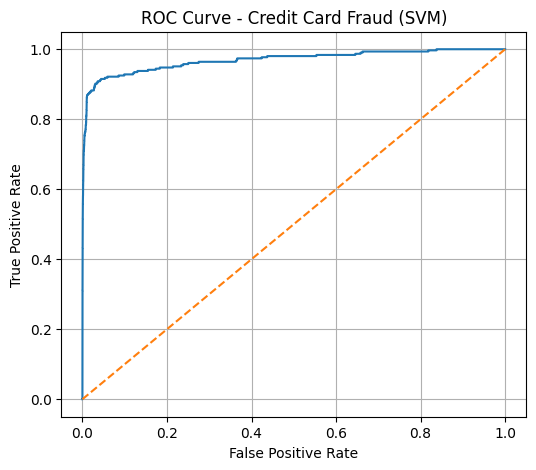

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(Y_test, Y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud (SVM)")
plt.grid(True)
plt.show()

**Add PR-AUC (Very Important for Extreme Imbalance)**

In [17]:
from sklearn.metrics import average_precision_score

print("PR-AUC:", average_precision_score(Y_test, Y_proba))

PR-AUC: 0.429107373264952


**Why RBF Kernel is Preferred Here**

Fraud patterns are rarely linearly separable.

RBF captures complex non-linear relationships.

class_weight='balanced' adjusts margin penalties for minority class.

ROC-AUC provides threshold-independent evaluation.

**Conclusion**

The SVM model with RBF kernel performs well for fraud detection when class weighting is used. Hyperparameter tuning of C and gamma improves model performance. ROC-AUC and F1-score provide better evaluation than accuracy, and the model effectively separates fraudulent and normal transactions.
